# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030


# Exercise 2 — Linear Regression: Predicting Body Weight

**Goal:** Predict a person's **Weight (kg)** using **Height (m)**, **Age (years)**, and **Gender** as independent variables.

We will:
1. Build the dataset
2. Explore it (EDA)
3. Encode the categorical variable (`Gender`)
4. Fit a Multiple Linear Regression model
5. Interpret coefficients, R², and significance (via `statsmodels`)
6. Fit the same model with `scikit-learn` and make a prediction on a new example


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
pd.set_option("display.precision", 3)


## 1. Build the dataset

The 10 observations given in the exercise.

In [2]:
data = {
    "Weight": [79, 69, 73, 95, 82, 55, 69, 71, 64, 69],
    "Height": [1.80, 1.68, 1.82, 1.70, 1.87, 1.55, 1.50, 1.78, 1.67, 1.64],
    "Age":    [35, 39, 25, 60, 27, 18, 89, 42, 16, 52],
    "Gender": ["Male", "Male", "Male", "Male", "Male",
               "Female", "Female", "Female", "Female", "Female"]
}

df = pd.DataFrame(data)
df


,Weight,Height,Age,Gender
0,79,1.80,35,Male
1,69,1.68,39,Male
2,73,1.82,25,Male
3,95,1.70,60,Male
4,82,1.87,27,Male
5,55,1.55,18,Female
6,69,1.50,89,Female
7,71,1.78,42,Female
8,64,1.67,16,Female
9,69,1.64,52,Female


## 2. Exploratory Data Analysis

In [3]:
df.describe(include="all")


,Weight,Height,Age,Gender
count,10.000,10.000,10.000,10
unique,NaN,NaN,NaN,2
top,NaN,NaN,NaN,Male
freq,NaN,NaN,NaN,5
mean,72.600,1.701,40.300,NaN
std,10.834,0.119,22.181,NaN
min,55.000,1.500,16.000,NaN
25%,69.000,1.647,25.500,NaN
50%,70.000,1.690,37.000,NaN
75%,77.500,1.795,49.500,NaN


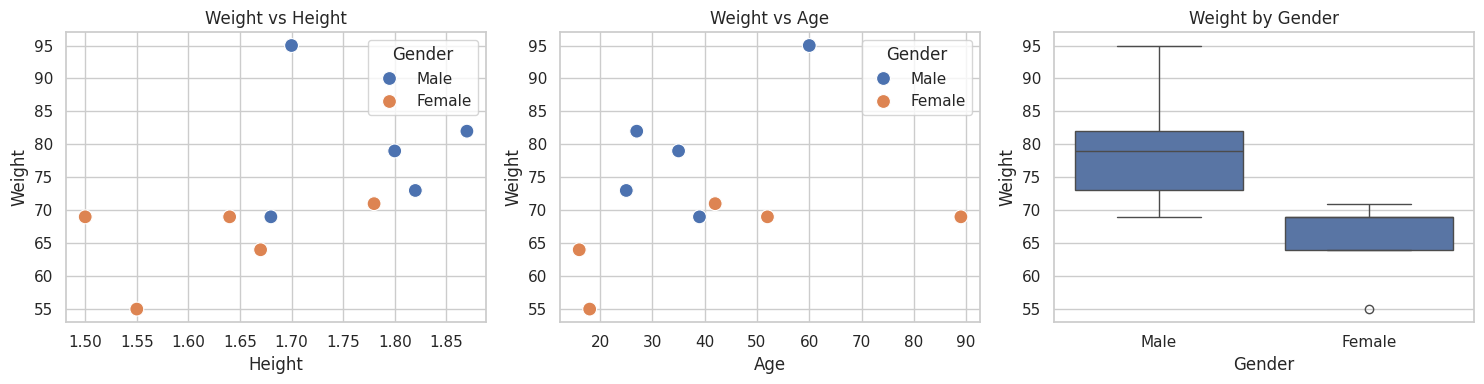

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(data=df, x="Height", y="Weight", hue="Gender", s=100, ax=axes[0])
axes[0].set_title("Weight vs Height")

sns.scatterplot(data=df, x="Age", y="Weight", hue="Gender", s=100, ax=axes[1])
axes[1].set_title("Weight vs Age")

sns.boxplot(data=df, x="Gender", y="Weight", ax=axes[2])
axes[2].set_title("Weight by Gender")

plt.tight_layout()
plt.show()


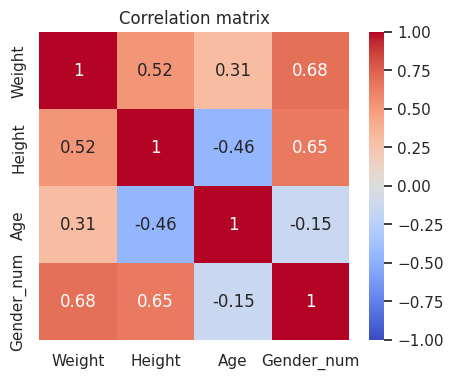

In [5]:
# Correlation heatmap (numeric only, gender encoded below for this view)
corr_df = df.copy()
corr_df["Gender_num"] = (corr_df["Gender"] == "Male").astype(int)
plt.figure(figsize=(5, 4))
sns.heatmap(corr_df[["Weight", "Height", "Age", "Gender_num"]].corr(),
            annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.show()


## 3. Encode the categorical variable

`Gender` is categorical (Male/Female). We encode it as a dummy/indicator variable:
`Gender_Male = 1` if Male, `0` if Female (Female becomes the reference category).


In [6]:
df_enc = df.copy()
df_enc["Gender_Male"] = (df_enc["Gender"] == "Male").astype(int)
df_enc = df_enc.drop(columns=["Gender"])
df_enc


,Weight,Height,Age,Gender_Male
0,79,1.80,35,1
1,69,1.68,39,1
2,73,1.82,25,1
3,95,1.70,60,1
4,82,1.87,27,1
5,55,1.55,18,0
6,69,1.50,89,0
7,71,1.78,42,0
8,64,1.67,16,0
9,69,1.64,52,0


## 4. Fit the model with `statsmodels` (for full statistical detail)

Model: `Weight = b0 + b1*Height + b2*Age + b3*Gender_Male + error`


In [7]:
X = df_enc[["Height", "Age", "Gender_Male"]]
y = df_enc["Weight"]

X_sm = sm.add_constant(X)  # adds the intercept term
model_sm = sm.OLS(y, X_sm).fit()

print(model_sm.summary())


                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.630
Method:                 Least Squares   F-statistic:                     6.115
Date:                Wed, 29 Jul 2026   Prob (F-statistic):             0.0296
Time:                        09:11:09   Log-Likelihood:                -30.487
No. Observations:                  10   AIC:                             68.97
Df Residuals:                       6   BIC:                             70.18
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -24.4097     47.641     -0.512      

### Interpreting the output

- **R-squared**: proportion of variance in Weight explained by Height, Age and Gender jointly.
- **coef** for `Height`: expected change in Weight (kg) per 1-meter increase in height, holding Age and Gender constant (in practice, interpret per 0.01 m i.e. per cm by dividing by 100).
- **coef** for `Age`: expected change in Weight per additional year, holding Height and Gender constant.
- **coef** for `Gender_Male`: expected difference in Weight between Males and Females (reference category), holding Height and Age constant.
- **P>|t|**: with only 10 observations and 3 predictors, statistical power is very low, so p-values should be read cautiously — this is a small illustrative dataset, not a basis for strong real-world claims.


## 5. Fit the same model with `scikit-learn`

In [8]:
lr = LinearRegression()
lr.fit(X, y)

print("Intercept (b0):", round(lr.intercept_, 3))
for name, coef in zip(X.columns, lr.coef_):
    print(f"Coefficient for {name}: {round(coef, 3)}")

y_pred = lr.predict(X)
print()
print("R^2  :", round(r2_score(y, y_pred), 3))
print("MAE  :", round(mean_absolute_error(y, y_pred), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y, y_pred)), 3))


Intercept (b0): -24.41
Coefficient for Height: 47.379
Coefficient for Age: 0.297
Coefficient for Gender_Male: 8.922

R^2  : 0.754
MAE  : 3.694
RMSE : 5.102


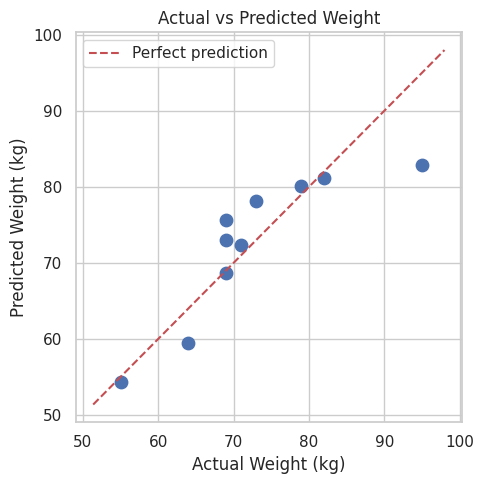

In [9]:
# Actual vs Predicted
plt.figure(figsize=(5, 5))
plt.scatter(y, y_pred, s=80)
lims = [min(y.min(), y_pred.min()) - 3, max(y.max(), y_pred.max()) + 3]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual Weight (kg)")
plt.ylabel("Predicted Weight (kg)")
plt.title("Actual vs Predicted Weight")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Predict the weight of a new person

Example: a 30-year-old Male, 1.75 m tall.


In [10]:
new_person = pd.DataFrame({
    "Height": [1.75],
    "Age": [30],
    "Gender_Male": [1]   # 1 = Male, 0 = Female
})

predicted_weight = lr.predict(new_person)[0]
print(f"Predicted weight: {predicted_weight:.2f} kg")


Predicted weight: 76.33 kg
